# Gap uv-fix test: LkCa_15_gap0 and DM_Tau_gap1

This notebook compares the original gap runs, made with the single-frequency `_lambda.vis.npz`, against one 50-mock rerun of each gap using the per-spw `_lambda_perspw.vis.npz` (`HPC_eqC1_gap_spartan/gap/*_uvfix`).

- **original (10 runs):** `HPC_eqC1_gap/gap/{gap}/recoveries/*_recoveries.combined.txt`, 500 mocks per bin.
- **uvfix:** `HPC_eqC1_gap_spartan/gap/{gap}_uvfix/recoveries/*_recoveries.0.txt`, 50 mocks per bin.

The plot uses criterion B only (Cycle 7 Handbook, 2σ with a 2-pixel floor), the criterion the summary plots use. The plot follows the style of `injrev_sum_plot.ipynb`: error bars are sqrt(n)/N, and dotted lines run from the axes to each F50 (blue = original, red = uvfix).

In [1]:
import glob, sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
sys.path.append(r"D:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as disk

orig_base = r"D:\CPD_MPIA\HPC_eqC1_gap\gap"
uvfix_base = r"D:\CPD_MPIA\HPC_eqC1_gap_spartan\gap"
gaps = [("LkCa_15", 0), ("DM_Tau", 1)]
npix_tol, ast_tol = 2, 2

def curves(dat, target, folder):
    # recovery fraction vs injected flux for criteria A and B (same as assess_recovery.ipynb)
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = dat.T
    azir = np.radians(azi)
    inclr, PAr = np.radians(disk.disk[target]['incl']), np.radians(disk.disk[target]['PA'])
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)
    d_ir = np.hypot(xi - xr, yi - yr)
    hd = fits.getheader(sorted(glob.glob(folder + '/recoveries/*.resid.fits'))[0])
    beam_fwhm = np.sqrt(3600**2 * hd['BMAJ'] * hd['BMIN'])
    pix_size = np.abs(3600 * hd['CDELT2'])
    vdat = np.load(rf"D:\exoALMA_disk_data\measurement_set_spavg\npz\{target}_time_ave_continuum_spavg_lambda.vis.npz")
    freq, wave = hd['CRVAL3'], 2.99792e5 / hd['CRVAL3']   # Hz, km
    Bmax_km = (wave * np.hypot(vdat['u'], vdat['v'])).max()
    sigma_A = (4 / np.pi)**0.25 * beam_fwhm * rms / (np.sqrt(8 * np.log(2)) * Fr)
    sigma_B = 70 / ((freq / 1e9) * Bmax_km * Fr / rms)
    Fcpd = np.unique(Fi)
    N = np.array([np.sum(Fi == F) for F in Fcpd])
    fA = np.array([np.mean((d_ir <= np.maximum(ast_tol * sigma_A, npix_tol * pix_size))[Fi == F]) for F in Fcpd])
    fB = np.array([np.mean((d_ir <= np.maximum(ast_tol * sigma_B, npix_tol * pix_size))[Fi == F]) for F in Fcpd])
    return Fcpd, N, fA, fB

def F50(Fcpd, fr):
    # first flux where the recovery fraction reaches 0.5, linearly interpolated
    i = np.argmax(fr >= 0.5)
    return np.nan if fr[i] < 0.5 else (Fcpd[0] if i == 0 else np.interp(0.5, fr[i - 1:i + 1], Fcpd[i - 1:i + 1]))

gap            F50_B original (10 runs)  F50_B uvfix (1 run)   (microJy)
LkCa_15_gap0                      137.0                126.3


DM_Tau_gap1                       101.0                116.7


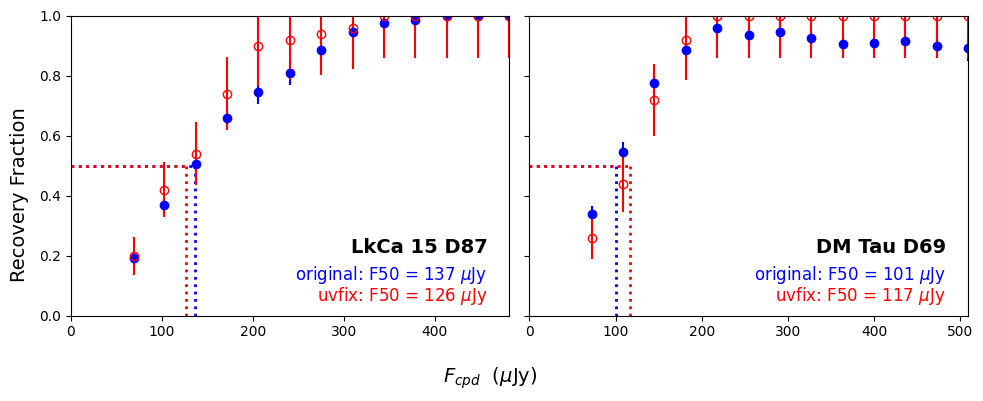

In [2]:
# style of injrev_sum_plot.ipynb: points only, sqrt(n)/N errors, dotted lines from the axes to each F50
fig, axes = plt.subplots(1, len(gaps), figsize=(10, 4), sharey=True)
print(f"{'gap':14s} {'F50_B original (10 runs)':>24s} {'F50_B uvfix (1 run)':>20s}   (microJy)")
for ax, (target, n) in zip(axes, gaps):
    name = f"{target}_gap{n}"
    runs = [(np.loadtxt(f"{orig_base}/{name}/recoveries/{name}_recoveries.combined.txt"), f"{orig_base}/{name}", "b", "original"),
            (np.loadtxt(f"{uvfix_base}/{name}_uvfix/recoveries/{name}_recoveries.0.txt"), f"{uvfix_base}/{name}_uvfix", "r", "uvfix")]
    D_au = disk.disk[target]["rgap"][n] * disk.disk[target]["distance"]
    ax.text(0.95, 0.05 + 0.08 * len(runs), f"{target.replace('_', ' ')} D{D_au:.0f}", transform=ax.transAxes,
            ha="right", fontsize=14, fontweight="bold")
    F50s = []
    for j, (dat, folder, c, label) in enumerate(runs):
        Fcpd, N, fA, frec_B = curves(dat, target, folder)
        ax.errorbar(Fcpd, frec_B, yerr=np.sqrt(frec_B * N) / N, marker="o", color=c, mfc=c if j == 0 else "none",
                    ls="none", capsize=0.0, elinewidth=1.5)
        F50B = F50(Fcpd, frec_B)
        ax.hlines(0.5, 0, F50B, color=c, ls=":", lw=2)
        ax.vlines(F50B, 0, 0.5, color=c, ls=":", lw=2)
        ax.text(0.95, 0.05 + 0.07 * (len(runs) - 1 - j), rf"{label}: F50 = {F50B:.0f} $\mu$Jy", color=c,
                transform=ax.transAxes, ha="right", fontsize=12)
        F50s.append(F50B)
    print(f"{name:14s} {F50s[0]:24.1f} {F50s[1]:20.1f}")
    ax.set_xlim(0, np.max(Fcpd))
    ax.set_ylim(0, 1)
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize=14)
fig.supylabel("Recovery Fraction", fontsize=14)
fig.tight_layout()
plt.show()